# Notes

1. In general in models, fnid the dynamics under the desired measure. Then, find the distribution of such measure, its expectation and variance.
If it is normally distributed, use Bachelier option pricing for european call/put
If it is lognormally distributed, use Black option pricing


# General

1. How to calibrate a model not only at time t (all parameters calibrated using historical data of time t).
How to model parameters using forward looking measure (implied vol surface, earnings call / fed's meeting, …)

## Packages

In [4]:
## packages
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%matplotlib widget
from scipy.stats import norm

## seed
np.random.seed(123)

## Humped yield curve

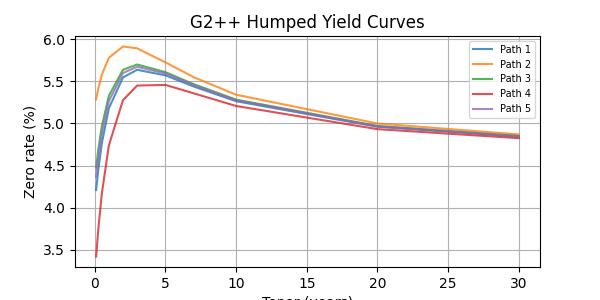

In [6]:
"""
This is a test to see how the model can fit humped curve,  the one we have seen last summer.
"""
def BondPrice(t, T, a, b, sigma, eta, rho, x_t, y_t):
    """
    Function to get bond price at time t, with maturity T, derived from x(t) and y(t)
    """

    def M(t, T, a, b, x_t, y_t):
        return ((1 - np.exp(-a*(T-t)))/a)*x_t + ((1 - np.exp(-b*(T-t)))/b)*y_t
    def V(t, T, a, b, sigma, eta, rho):
        term1 = (sigma**2 / a**2) * (T - t + (2/a)*np.exp(-a*(T-t)) - (1/(2*a))*np.exp(-2*a*(T-t)) - (3/(2*a)))
        term2 = (eta**2 / b**2) * (T - t + (2/b)*np.exp(-b*(T-t)) - (1/(2*b))*np.exp(-2*b*(T-t)) - (3/(2*b)))
        term3 = (2*rho*sigma*eta/(a*b)) * (T - t + (np.exp(-a*(T-t))-1)/a + (np.exp(-b*(T-t))-1)/b - (np.exp(-(a+b)*(T-t))-1)/(a+b))
        return term1 + term2 + term3
    global phi
    int_phi = phi(t)*(T-t)    # defined as a constant for simplicity, to be adjusted
    BondPrice = np.exp(-int_phi - M(t, T, a, b, x_t, y_t) + 0.5*V(t, T, a, b, sigma, eta, rho))

    return BondPrice

def BondYield(t, T, a, b, sigma, eta, rho, x_t, y_t):
    BondYield = -np.log(BondPrice(t, T, a, b, sigma, eta, rho, x_t, y_t)) / (T - t)
    return  BondYield

"""
Now the humped curve
"""
# parameters for humped curves
a     = 1.5    # very fast → x effect vanishes by 1-2 years
b     = 0.3    # moderate → y decays over 5-10 years
sigma = 0.08
eta   = 0.04
rho   = -0.9

def phi(t):
    return 0.05   # 5% base rate

M = 5          #simulate 5 independant paths
tenors   = np.array([0.1, 0.25, 0.5, 1, 2, 3, 5, 7, 10, 20, 30])
t_target = 1  # curve at t=1 for each simulation

# x < 0 and y > 0 → this is what creates the hump
x_vals = np.random.uniform(-0.04, -0.01, M)
y_vals = np.random.uniform(0.02, 0.02, M)

yields_humped = np.zeros((M, len(tenors)))
for m in range(M):
    T_vec = t_target + tenors
    yields_humped[m, :] = BondYield(t_target, T_vec, a, b, sigma, eta, rho, x_vals[m], y_vals[m])

plt.figure(figsize=(6, 3))
for m in range(M):
    plt.plot(tenors, yields_humped[m, :] * 100, alpha=0.8, label=f'Path {m+1}')
plt.xlabel('Tenor (years)')
plt.ylabel('Zero rate (%)')
plt.title('G2++ Humped Yield Curves')
plt.legend(fontsize=7)
plt.grid()
plt.show()

testing of meshing in binomial tree:

In [ ]:
# example parameters
sigma = 0.04
eta   = 0.02
dt    = 0.5       # example time step
dx    = sigma * np.sqrt(dt)
dy    = eta   * np.sqrt(dt)

n = 3

I, J = np.meshgrid(np.arange(n+1), np.arange(n+1), indexing='ij')
x = (2*I - n) * dx
y = (2*J - n) * dy

print("I:\n", I)
print("J:\n", J)
print("x:\n", x.round(4))
print("y:\n", y.round(4))
print("(x,y) at each node:")
for i in range(n+1):
    for j in range(n+1):
        print(f"  ({i},{j}): x={x[i,j]:.4f}, y={y[i,j]:.4f}")

Vasicek model Schrager-Pelsser approximation:

<div style="background-color: #ffcdcd; padding: 10px; border-left: 4px solid #ff8b07;">
⚠️ <b>TO REMOVE :</b> 
</div>

_____

**For the Vasicek model:**

Now for the forward swap rate, under the forward swap measure $Q^{n+1,N}$
$$
dy_{n,N}(t) = \sigma \frac{\partial y_{n,N}(t)}{\partial r(t)} dW_t^{Q^{n+1,N}}
$$
where 
$$
\begin{aligned}
\frac{\partial y_{n,N}(t)}{\partial r(t)} &= -B(t,T_n)D^P(t,T_n) + B(t,T_N)D^P(t,T_N)
\\\\&
+ y_{n,N}(t) \sum_{i=n+1}^{N} \Delta_{i-1}^Y B(t, T_i) D^P(t, T_i)
\end{aligned}
$$
where $D^P(t,T_n) = D(t,T_n)/P_{n+1,N}(t)$, the bond price normalized by the numéraire

**Schrager Pelsser approximation:**

Approximate $D^P(t, T_n)$ by its conditional expectation under the forward swap measure, $D^P(0, T_n)$

Approximate the swap rate itself in the volatility by its martingale value.

That is, $\frac{\partial y_{n,N}(t)}{\partial r(t)} \approx \widetilde{\frac{\partial y_{n,N}(t)}{\partial r(t)}}$ where

$$
\begin{aligned}
\widetilde{\frac{\partial y_{n,N}(t)}{\partial r(t)}} &= -B(t,T_n)D^P(0,T_n) + B(t,T_N)D^P(0,T_N)
\\\\&
+ y_{n,N}(0) \sum_{i=n+1}^{N} \Delta_{i-1}^Y B(t, T_i) D^P(0, T_i)
\end{aligned}
$$
Note, $B(t, T) = \frac{1}{a} - \frac{e^{-aT}}{a} e^{at}$

<div style="background-color: #ffcdcd; padding: 10px; border-left: 4px solid #ff8b07;">
⚠️ <b>TO REMOVE ^</b> 
</div>